In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
BASE_DIR = Path("..").resolve()
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIG_DIR = BASE_DIR / "figures" / "part3"
OUT_DIR = BASE_DIR / "outputs" / "part3"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
cpi_path = RAW_DIR / "CPI_DATA.xlsx"
cpi_path

PosixPath('/Users/marwanferreira/Desktop/audusd-carry-uip-ppp/data/raw/CPI_DATA.xlsx')

In [9]:
xls = pd.ExcelFile(cpi_path)
xls.sheet_names

['CPI- US DATA',
 'CPI - Canada',
 'CPI - Mexico',
 'CPI - Japan',
 'CPI - EURO',
 'CPI - Australia']

In [11]:
us_sheet = xls.sheet_names[0]
au_sheet = xls.sheet_names[5]

cpi_us_raw = pd.read_excel(cpi_path, sheet_name=us_sheet)
cpi_au_raw = pd.read_excel(cpi_path, sheet_name=au_sheet)

print("US shape:", cpi_us_raw.shape)
print("AU shape:", cpi_au_raw.shape)

cpi_us_raw.head(10)

US shape: (1358, 4)
AU shape: (456, 2)


,observation_date,Unnamed: 1,Period,Actual (Revised)
0,1913-01-01,1912-12-31,1912-12-31,9.8
1,1913-02-01,1913-01-31,1913-01-31,9.8
2,1913-03-01,1913-02-28,1913-02-28,9.8
3,1913-04-01,1913-03-31,1913-03-31,9.8
4,1913-05-01,1913-04-30,1913-04-30,9.7
5,1913-06-01,1913-05-31,1913-05-31,9.8
6,1913-07-01,1913-06-30,1913-06-30,9.9
7,1913-08-01,1913-07-31,1913-07-31,9.9
8,1913-09-01,1913-08-31,1913-08-31,10.0
9,1913-10-01,1913-09-30,1913-09-30,10.0


In [12]:
print("US columns:", cpi_us_raw.columns.tolist())
print("AU columns:", cpi_au_raw.columns.tolist())

US columns: ['observation_date', 'Unnamed: 1', 'Period', 'Actual (Revised)']
AU columns: ['Period', 'Actual (Revised)']


In [13]:
cpi_us = cpi_us_raw[["observation_date", "Actual (Revised)"]].copy()
cpi_us.columns = ["Date", "cpi_us"]

cpi_us["Date"] = pd.to_datetime(cpi_us["Date"])
cpi_us["cpi_us"] = pd.to_numeric(cpi_us["cpi_us"], errors="coerce")

cpi_us = cpi_us.dropna().sort_values("Date").reset_index(drop=True)
cpi_us.head()

,Date,cpi_us
0,1913-01-01,9.8
1,1913-02-01,9.8
2,1913-03-01,9.8
3,1913-04-01,9.8
4,1913-05-01,9.7


In [14]:
cpi_au = cpi_au_raw[["Period", "Actual (Revised)"]].copy()
cpi_au.columns = ["Date", "cpi_au"]

cpi_au["Date"] = pd.to_datetime(cpi_au["Date"])
cpi_au["cpi_au"] = pd.to_numeric(cpi_au["cpi_au"], errors="coerce")

cpi_au = cpi_au.dropna().sort_values("Date").reset_index(drop=True)
cpi_au.head()

,Date,cpi_au
0,1988-03-31,33.630000
1,1988-04-30,33.823333
2,1988-05-31,34.016667
3,1988-06-30,34.210000
4,1988-07-31,34.430000


In [23]:
cpi_us["Month"] = cpi_us["Date"].dt.to_period("M")
cpi_au["Month"] = cpi_au["Date"].dt.to_period("M")

cpi = pd.merge(
    cpi_au[["Month", "cpi_au"]],
    cpi_us[["Month", "cpi_us"]],
    on="Month",
    how="inner"
)

cpi["Date"] = cpi["Month"].dt.to_timestamp("M")
cpi = cpi[["Date", "cpi_au", "cpi_us"]].copy()

cpi["infl_au"] = np.log(cpi["cpi_au"]).diff()
cpi["infl_us"] = np.log(cpi["cpi_us"]).diff()
cpi["infl_diff"] = cpi["infl_au"] - cpi["infl_us"]

cpi = cpi[(cpi["Date"] >= "2009-01-01") & (cpi["Date"] <= "2023-12-31")].copy()
cpi.reset_index(drop=True, inplace=True)

print(cpi.shape)
cpi.head(12)

(180, 6)


,Date,cpi_au,cpi_us,infl_au,infl_us,infl_diff
0,2009-01-31,64.183333,211.143,0.000364,0.004343,-0.003979
1,2009-02-28,64.206667,212.193,0.000363,0.004961,-0.004597
2,2009-03-31,64.230000,212.709,0.000363,0.002429,-0.002065
3,2009-04-30,64.336667,213.240,0.001659,0.002493,-0.000834
4,2009-05-31,64.443333,213.856,0.001657,0.002885,-0.001228
5,2009-06-30,64.550000,215.693,0.001654,0.008553,-0.006899
6,2009-07-31,64.753333,215.351,0.003145,-0.001587,0.004732
7,2009-08-31,64.956667,215.834,0.003135,0.002240,0.000895
8,2009-09-30,65.160000,215.969,0.003125,0.000625,0.002500
9,2009-10-31,65.276667,216.177,0.001789,0.000963,0.000826


In [24]:
cpi.to_csv(PROCESSED_DIR / "audusd_cpi_processed.csv", index=False)

In [25]:
import yfinance as yf

In [26]:
audusd_daily = yf.download(
    "AUDUSD=X",
    start="2008-12-01",
    end="2024-01-31",
    auto_adjust=False,
    progress=False
)

audusd_daily.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AUDUSD=X,AUDUSD=X,AUDUSD=X,AUDUSD=X,AUDUSD=X,AUDUSD=X
Date,,,,,,
2008-12-01,0.635203,0.635203,0.651976,0.634880,0.651381,0
2008-12-02,0.643170,0.643170,0.648593,0.634800,0.635405,0
2008-12-03,0.648214,0.648214,0.651381,0.640000,0.643211,0
2008-12-04,0.643542,0.643542,0.653381,0.640943,0.647082,0
2008-12-05,0.648298,0.648298,0.649014,0.630120,0.643418,0


In [27]:
audusd_daily.columns

MultiIndex([('Adj Close', 'AUDUSD=X'),
            (    'Close', 'AUDUSD=X'),
            (     'High', 'AUDUSD=X'),
            (      'Low', 'AUDUSD=X'),
            (     'Open', 'AUDUSD=X'),
            (   'Volume', 'AUDUSD=X')],
           names=['Price', 'Ticker'])

In [28]:
if "Adj Close" in audusd_daily.columns:
    audusd_daily["spot"] = audusd_daily["Adj Close"]
else:
    audusd_daily["spot"] = audusd_daily["Close"]

audusd_daily = audusd_daily[["spot"]].copy()
audusd_daily = audusd_daily.reset_index()
audusd_daily.head()

Price,Date,spot
Ticker,,
0,2008-12-01,0.635203
1,2008-12-02,0.643170
2,2008-12-03,0.648214
3,2008-12-04,0.643542
4,2008-12-05,0.648298


In [29]:
audusd_monthly = audusd_daily.copy()
audusd_monthly["Date"] = pd.to_datetime(audusd_monthly["Date"])
audusd_monthly = (
    audusd_monthly
    .set_index("Date")
    .resample("M")
    .last()
    .dropna()
    .reset_index()
)

audusd_monthly.head(12)

Price,Date,spot
Ticker,,
0,2008-12-31,0.705517
1,2009-01-31,0.638488
2,2009-02-28,0.642219
3,2009-03-31,0.691802
4,2009-04-30,0.726691
5,2009-05-31,0.801025
6,2009-06-30,0.806192
7,2009-07-31,0.835631
8,2009-08-31,0.842886


In [30]:
audusd_monthly = audusd_monthly[
    (audusd_monthly["Date"] >= "2009-01-01") &
    (audusd_monthly["Date"] <= "2023-12-31")
].copy()

audusd_monthly.reset_index(drop=True, inplace=True)

print(audusd_monthly.shape)
audusd_monthly.head()

(180, 2)


Price,Date,spot
Ticker,,
0,2009-01-31,0.638488
1,2009-02-28,0.642219
2,2009-03-31,0.691802
3,2009-04-30,0.726691
4,2009-05-31,0.801025


In [31]:
audusd_monthly["fx_return"] = np.log(audusd_monthly["spot"]).diff()
audusd_monthly.head(12)

Price,Date,spot,fx_return
Ticker,,,
0,2009-01-31,0.638488,NaN
1,2009-02-28,0.642219,0.005827
2,2009-03-31,0.691802,0.074370
3,2009-04-30,0.726691,0.049202
4,2009-05-31,0.801025,0.097391
5,2009-06-30,0.806192,0.006429
6,2009-07-31,0.835631,0.035866
7,2009-08-31,0.842886,0.008644
8,2009-09-30,0.883783,0.047379


In [32]:
audusd_monthly.to_csv(PROCESSED_DIR / "audusd_spot_processed.csv", index=False)

In [33]:
# US 1-month Treasury yield from FRED
us_rate = pd.read_csv(
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS1MO"
)

# Australia cash rate target from RBA
au_rate = pd.read_csv(
    "https://www.rba.gov.au/statistics/tables/csv/f1.1-data.csv"
)

In [34]:
print(us_rate.head())
print(us_rate.columns.tolist())

print(au_rate.head())
print(au_rate.columns.tolist())

  observation_date  DGS1MO
0       2001-07-31    3.67
1       2001-08-01    3.65
2       2001-08-02    3.65
3       2001-08-03    3.63
4       2001-08-06    3.62
['observation_date', 'DGS1MO']
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        F1.1 INTEREST RATES AND YIELDS – MONEY MARKET
Title       Cash Rate Target                  Interbank Overnight Cash Rate      

In [36]:
us_rate = us_rate.rename(columns={
    "observation_date": "Date",
    "DGS1MO": "rate_us"
})

us_rate["Date"] = pd.to_datetime(us_rate["Date"])
us_rate["rate_us"] = pd.to_numeric(us_rate["rate_us"], errors="coerce")

us_rate = us_rate.dropna().copy()

us_rate = (
    us_rate.set_index("Date")
    .resample("M")
    .last()
    .reset_index()
)

us_rate.head()

,Date,rate_us
0,2001-07-31,3.67
1,2001-08-31,3.40
2,2001-09-30,2.28
3,2001-10-31,2.15
4,2001-11-30,1.87


In [37]:
print(us_rate.shape)
us_rate.head()
us_rate.tail()

(299, 2)


,Date,rate_us
294,2026-01-31,3.72
295,2026-02-28,3.74
296,2026-03-31,3.74
297,2026-04-30,3.72
298,2026-05-31,3.71


In [39]:
print(au_rate.columns.tolist())

['F1.1 INTEREST RATES AND YIELDS – MONEY MARKET']


In [40]:
au_rate.head(15)

,,,,,,,,,,,,,,,F1.1 INTEREST RATES AND YIELDS – MONEY MARKET
Title,Cash Rate Target,Interbank Overnight Cash Rate,Highest Interbank Overnight Cash Rate,Lowest Interbank Overnight Cash Rate,Volume of Cash Market Transactions,Number of Cash Market Transactions,1-month BABs/NCDs,3-month BABs/NCDs,6-month BABs/NCDs,1-month OIS,3-month OIS,6-month OIS,1-month Treasury Note,3- month Treasury Note,6- month Treasury Note
Description,Cash Rate Target; monthly average,Interbank Overnight Cash Rate; monthly average,Highest Interbank Overnight Cash Rate; monthly average,Lowest Interbank Overnight Cash Rate; monthly average,Volume of Interbank Overnight Cash Market Transactions; monthly sum,Number of Interbank Overnight Cash Market Transactions; monthly sum,Bank Accepted Bills/Negotiable Certificates of Deposit-1 month; monthly average,Bank Accepted Bills/Negotiable Certificates of Deposit-3 months; monthly average,Bank Accepted Bills/Negotiable Certificates of Deposit- 6 months; monthly average,Overnight Indexed Swaps-1 month; monthly average,Overnight Indexed Swaps-3 months; monthly average,Overnight Indexed Swaps-6 months; monthly average,Treasury Notes-1 month; monthly average,Treasury Notes-3 months; monthly average,Treasury Notes-6 months; monthly average
Frequency,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,See notes,See notes,See notes
Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
Units,Per cent,Per cent,Per cent,Per cent,$m,Number,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent
Source,RBA,RBA,RBA,RBA,RBA,RBA,ASX,ASX,ASX,FENICS,FENICS,FENICS,RBA,RBA,RBA
Publication date,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026
Series ID,FIRMMCRT,FIRMMCRI,FIRMMCRIHM,FIRMMCRILM,FIRMMCRIVM,FIRMMCRINM,FIRMMBAB30,FIRMMBAB90,FIRMMBAB180,FIRMMOIS1,FIRMMOIS3,FIRMMOIS6,FIRMMTN1,FIRMMTN3,FIRMMTN6
30/06/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31/07/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
au_rate_reset = au_rate.copy().reset_index()
print(au_rate_reset.columns.tolist())

['level_0', 'level_1', 'level_2', 'level_3', 'level_4', 'level_5', 'level_6', 'level_7', 'level_8', 'level_9', 'level_10', 'level_11', 'level_12', 'level_13', 'level_14', 'F1.1 INTEREST RATES AND YIELDS – MONEY MARKET']


In [45]:
print(type(au_rate.columns))

<class 'pandas.core.indexes.base.Index'>


In [46]:
au_rate_flat = au_rate.copy()

if isinstance(au_rate_flat.columns, pd.MultiIndex):
    au_rate_flat.columns = au_rate_flat.columns.get_level_values(0)

print(au_rate_flat.columns.tolist())
au_rate_flat.head(10)

['F1.1 INTEREST RATES AND YIELDS – MONEY MARKET']


,,,,,,,,,,,,,,,F1.1 INTEREST RATES AND YIELDS – MONEY MARKET
Title,Cash Rate Target,Interbank Overnight Cash Rate,Highest Interbank Overnight Cash Rate,Lowest Interbank Overnight Cash Rate,Volume of Cash Market Transactions,Number of Cash Market Transactions,1-month BABs/NCDs,3-month BABs/NCDs,6-month BABs/NCDs,1-month OIS,3-month OIS,6-month OIS,1-month Treasury Note,3- month Treasury Note,6- month Treasury Note
Description,Cash Rate Target; monthly average,Interbank Overnight Cash Rate; monthly average,Highest Interbank Overnight Cash Rate; monthly average,Lowest Interbank Overnight Cash Rate; monthly average,Volume of Interbank Overnight Cash Market Transactions; monthly sum,Number of Interbank Overnight Cash Market Transactions; monthly sum,Bank Accepted Bills/Negotiable Certificates of Deposit-1 month; monthly average,Bank Accepted Bills/Negotiable Certificates of Deposit-3 months; monthly average,Bank Accepted Bills/Negotiable Certificates of Deposit- 6 months; monthly average,Overnight Indexed Swaps-1 month; monthly average,Overnight Indexed Swaps-3 months; monthly average,Overnight Indexed Swaps-6 months; monthly average,Treasury Notes-1 month; monthly average,Treasury Notes-3 months; monthly average,Treasury Notes-6 months; monthly average
Frequency,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,See notes,See notes,See notes
Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
Units,Per cent,Per cent,Per cent,Per cent,$m,Number,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent
Source,RBA,RBA,RBA,RBA,RBA,RBA,ASX,ASX,ASX,FENICS,FENICS,FENICS,RBA,RBA,RBA
Publication date,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026
Series ID,FIRMMCRT,FIRMMCRI,FIRMMCRIHM,FIRMMCRILM,FIRMMCRIVM,FIRMMCRINM,FIRMMBAB30,FIRMMBAB90,FIRMMBAB180,FIRMMOIS1,FIRMMOIS3,FIRMMOIS6,FIRMMTN1,FIRMMTN3,FIRMMTN6
30/06/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31/07/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
au_rate_clean = au_rate_flat.copy()

# the index/row labels still contain the dates + metadata, so reset that
au_rate_clean = au_rate_clean.reset_index()

print(au_rate_clean.columns.tolist())
au_rate_clean.head(10)

['level_0', 'level_1', 'level_2', 'level_3', 'level_4', 'level_5', 'level_6', 'level_7', 'level_8', 'level_9', 'level_10', 'level_11', 'level_12', 'level_13', 'level_14', 'F1.1 INTEREST RATES AND YIELDS – MONEY MARKET']


,level_0,level_1,level_2,level_3,level_4,level_5,level_6,level_7,level_8,level_9,level_10,level_11,level_12,level_13,level_14,F1.1 INTEREST RATES AND YIELDS – MONEY MARKET
0,Title,Cash Rate Target,Interbank Overnight Cash Rate,Highest Interbank Overnight Cash Rate,Lowest Interbank Overnight Cash Rate,Volume of Cash Market Transactions,Number of Cash Market Transactions,1-month BABs/NCDs,3-month BABs/NCDs,6-month BABs/NCDs,1-month OIS,3-month OIS,6-month OIS,1-month Treasury Note,3- month Treasury Note,6- month Treasury Note
1,Description,Cash Rate Target; monthly average,Interbank Overnight Cash Rate; monthly average,Highest Interbank Overnight Cash Rate; monthly...,Lowest Interbank Overnight Cash Rate; monthly ...,Volume of Interbank Overnight Cash Market Tran...,Number of Interbank Overnight Cash Market Tran...,Bank Accepted Bills/Negotiable Certificates of...,Bank Accepted Bills/Negotiable Certificates of...,Bank Accepted Bills/Negotiable Certificates of...,Overnight Indexed Swaps-1 month; monthly average,Overnight Indexed Swaps-3 months; monthly average,Overnight Indexed Swaps-6 months; monthly average,Treasury Notes-1 month; monthly average,Treasury Notes-3 months; monthly average,Treasury Notes-6 months; monthly average
2,Frequency,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,See notes,See notes,See notes
3,Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
4,Units,Per cent,Per cent,Per cent,Per cent,$m,Number,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent
5,Source,RBA,RBA,RBA,RBA,RBA,RBA,ASX,ASX,ASX,FENICS,FENICS,FENICS,RBA,RBA,RBA
6,Publication date,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026
7,Series ID,FIRMMCRT,FIRMMCRI,FIRMMCRIHM,FIRMMCRILM,FIRMMCRIVM,FIRMMCRINM,FIRMMBAB30,FIRMMBAB90,FIRMMBAB180,FIRMMOIS1,FIRMMOIS3,FIRMMOIS6,FIRMMTN1,FIRMMTN3,FIRMMTN6
8,30/06/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,31/07/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
au_rate_clean = au_rate_clean.rename(columns={
    "index": "Date",
    "Cash Rate Target": "rate_au"
})

In [50]:
# Step 1: reset the weird structure
au_tmp = au_rate.copy().reset_index()

# Step 2: use the first row as the real header
au_tmp.columns = au_tmp.iloc[0]

# Step 3: drop that first row
au_tmp = au_tmp.iloc[1:].copy()

# Step 4: inspect
print(au_tmp.columns.tolist())
au_tmp.head(10)

['Title', 'Cash Rate Target', 'Interbank Overnight Cash Rate', 'Highest Interbank Overnight Cash Rate', 'Lowest Interbank Overnight Cash Rate', 'Volume of Cash Market Transactions', 'Number of Cash Market Transactions', '1-month BABs/NCDs', '3-month BABs/NCDs', '6-month BABs/NCDs', '1-month OIS', '3-month OIS', '6-month OIS', '1-month Treasury Note', '3- month Treasury Note', '6- month Treasury Note']


,Title,Cash Rate Target,Interbank Overnight Cash Rate,Highest Interbank Overnight Cash Rate,Lowest Interbank Overnight Cash Rate,Volume of Cash Market Transactions,Number of Cash Market Transactions,1-month BABs/NCDs,3-month BABs/NCDs,6-month BABs/NCDs,1-month OIS,3-month OIS,6-month OIS,1-month Treasury Note,3- month Treasury Note,6- month Treasury Note
1,Description,Cash Rate Target; monthly average,Interbank Overnight Cash Rate; monthly average,Highest Interbank Overnight Cash Rate; monthly...,Lowest Interbank Overnight Cash Rate; monthly ...,Volume of Interbank Overnight Cash Market Tran...,Number of Interbank Overnight Cash Market Tran...,Bank Accepted Bills/Negotiable Certificates of...,Bank Accepted Bills/Negotiable Certificates of...,Bank Accepted Bills/Negotiable Certificates of...,Overnight Indexed Swaps-1 month; monthly average,Overnight Indexed Swaps-3 months; monthly average,Overnight Indexed Swaps-6 months; monthly average,Treasury Notes-1 month; monthly average,Treasury Notes-3 months; monthly average,Treasury Notes-6 months; monthly average
2,Frequency,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,See notes,See notes,See notes
3,Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
4,Units,Per cent,Per cent,Per cent,Per cent,$m,Number,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent
5,Source,RBA,RBA,RBA,RBA,RBA,RBA,ASX,ASX,ASX,FENICS,FENICS,FENICS,RBA,RBA,RBA
6,Publication date,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026
7,Series ID,FIRMMCRT,FIRMMCRI,FIRMMCRIHM,FIRMMCRILM,FIRMMCRIVM,FIRMMCRINM,FIRMMBAB30,FIRMMBAB90,FIRMMBAB180,FIRMMOIS1,FIRMMOIS3,FIRMMOIS6,FIRMMTN1,FIRMMTN3,FIRMMTN6
8,30/06/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,31/07/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,31/08/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
au_rate_clean = au_tmp.rename(columns={
    "Title": "Date",
    "Cash Rate Target": "rate_au"
})

au_rate_clean["Date"] = pd.to_datetime(
    au_rate_clean["Date"],
    dayfirst=True,
    errors="coerce"
)

au_rate_clean["rate_au"] = pd.to_numeric(
    au_rate_clean["rate_au"],
    errors="coerce"
)

au_rate_clean = au_rate_clean.dropna(subset=["Date", "rate_au"]).copy()

au_rate_clean = (
    au_rate_clean[["Date", "rate_au"]]
    .set_index("Date")
    .resample("M")
    .last()
    .reset_index()
)

au_rate_clean = au_rate_clean[
    (au_rate_clean["Date"] >= "2009-01-01") &
    (au_rate_clean["Date"] <= "2023-12-31")
].copy()

au_rate_clean.reset_index(drop=True, inplace=True)

print(au_rate_clean.shape)
au_rate_clean.head()
au_rate_clean.tail()

(180, 2)


/var/folders/t4/q542qsks2b35pwzxx6r7rv3r0000gn/T/ipykernel_25503/2508022573.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  au_rate_clean["Date"] = pd.to_datetime(


,Date,rate_au
175,2023-08-31,4.10
176,2023-09-30,4.10
177,2023-10-31,4.10
178,2023-11-30,4.29
179,2023-12-31,4.35


In [52]:
au_tmp = au_rate.copy().reset_index()
au_tmp.columns = au_tmp.iloc[0]
au_tmp = au_tmp.iloc[1:].copy()

print(au_tmp.columns.tolist())
au_tmp.head(10)

['Title', 'Cash Rate Target', 'Interbank Overnight Cash Rate', 'Highest Interbank Overnight Cash Rate', 'Lowest Interbank Overnight Cash Rate', 'Volume of Cash Market Transactions', 'Number of Cash Market Transactions', '1-month BABs/NCDs', '3-month BABs/NCDs', '6-month BABs/NCDs', '1-month OIS', '3-month OIS', '6-month OIS', '1-month Treasury Note', '3- month Treasury Note', '6- month Treasury Note']


,Title,Cash Rate Target,Interbank Overnight Cash Rate,Highest Interbank Overnight Cash Rate,Lowest Interbank Overnight Cash Rate,Volume of Cash Market Transactions,Number of Cash Market Transactions,1-month BABs/NCDs,3-month BABs/NCDs,6-month BABs/NCDs,1-month OIS,3-month OIS,6-month OIS,1-month Treasury Note,3- month Treasury Note,6- month Treasury Note
1,Description,Cash Rate Target; monthly average,Interbank Overnight Cash Rate; monthly average,Highest Interbank Overnight Cash Rate; monthly...,Lowest Interbank Overnight Cash Rate; monthly ...,Volume of Interbank Overnight Cash Market Tran...,Number of Interbank Overnight Cash Market Tran...,Bank Accepted Bills/Negotiable Certificates of...,Bank Accepted Bills/Negotiable Certificates of...,Bank Accepted Bills/Negotiable Certificates of...,Overnight Indexed Swaps-1 month; monthly average,Overnight Indexed Swaps-3 months; monthly average,Overnight Indexed Swaps-6 months; monthly average,Treasury Notes-1 month; monthly average,Treasury Notes-3 months; monthly average,Treasury Notes-6 months; monthly average
2,Frequency,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,See notes,See notes,See notes
3,Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original
4,Units,Per cent,Per cent,Per cent,Per cent,$m,Number,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent,Per cent
5,Source,RBA,RBA,RBA,RBA,RBA,RBA,ASX,ASX,ASX,FENICS,FENICS,FENICS,RBA,RBA,RBA
6,Publication date,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026,01-May-2026
7,Series ID,FIRMMCRT,FIRMMCRI,FIRMMCRIHM,FIRMMCRILM,FIRMMCRIVM,FIRMMCRINM,FIRMMBAB30,FIRMMBAB90,FIRMMBAB180,FIRMMOIS1,FIRMMOIS3,FIRMMOIS6,FIRMMTN1,FIRMMTN3,FIRMMTN6
8,30/06/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,31/07/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,31/08/1969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
au_rate_clean = au_tmp.rename(columns={
    "Title": "Date",
    "Cash Rate Target": "rate_au"
})

au_rate_clean["Date"] = pd.to_datetime(
    au_rate_clean["Date"],
    dayfirst=True,
    errors="coerce"
)

au_rate_clean["rate_au"] = pd.to_numeric(
    au_rate_clean["rate_au"],
    errors="coerce"
)

au_rate_clean = au_rate_clean.dropna(subset=["Date", "rate_au"]).copy()

au_rate_clean = (
    au_rate_clean[["Date", "rate_au"]]
    .set_index("Date")
    .resample("M")
    .last()
    .reset_index()
)

au_rate_clean = au_rate_clean[
    (au_rate_clean["Date"] >= "2009-01-01") &
    (au_rate_clean["Date"] <= "2023-12-31")
].copy()

au_rate_clean.reset_index(drop=True, inplace=True)

print(au_rate_clean.shape)
au_rate_clean.head()

(180, 2)


/var/folders/t4/q542qsks2b35pwzxx6r7rv3r0000gn/T/ipykernel_25503/816978734.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  au_rate_clean["Date"] = pd.to_datetime(


,Date,rate_au
0,2009-01-31,4.25
1,2009-02-28,3.35
2,2009-03-31,3.25
3,2009-04-30,3.06
4,2009-05-31,3.00


In [54]:
au_rate_clean.tail()

,Date,rate_au
175,2023-08-31,4.10
176,2023-09-30,4.10
177,2023-10-31,4.10
178,2023-11-30,4.29
179,2023-12-31,4.35


In [55]:
spot = pd.read_csv(PROCESSED_DIR / "audusd_spot_processed.csv", parse_dates=["Date"])
cpi = pd.read_csv(PROCESSED_DIR / "audusd_cpi_processed.csv", parse_dates=["Date"])

strategy_data = (
    spot.merge(au_rate_clean, on="Date", how="inner")
        .merge(us_rate, on="Date", how="inner")
        .merge(cpi, on="Date", how="left")
        .sort_values("Date")
        .reset_index(drop=True)
)

print(strategy_data.shape)
strategy_data.head(12)

(180, 10)


,Date,spot,fx_return,rate_au,rate_us,cpi_au,cpi_us,infl_au,infl_us,infl_diff
0,2009-01-31,0.638488,NaN,4.25,0.15,64.183333,211.143,0.000364,0.004343,-0.003979
1,2009-02-28,0.642219,0.005827,3.35,0.16,64.206667,212.193,0.000363,0.004961,-0.004597
2,2009-03-31,0.691802,0.074370,3.25,0.17,64.230000,212.709,0.000363,0.002429,-0.002065
3,2009-04-30,0.726691,0.049202,3.06,0.04,64.336667,213.240,0.001659,0.002493,-0.000834
4,2009-05-31,0.801025,0.097391,3.00,0.14,64.443333,213.856,0.001657,0.002885,-0.001228
5,2009-06-30,0.806192,0.006429,3.00,0.17,64.550000,215.693,0.001654,0.008553,-0.006899
6,2009-07-31,0.835631,0.035866,3.00,0.14,64.753333,215.351,0.003145,-0.001587,0.004732
7,2009-08-31,0.842886,0.008644,3.00,0.11,64.956667,215.834,0.003135,0.002240,0.000895
8,2009-09-30,0.883783,0.047379,3.00,0.06,65.160000,215.969,0.003125,0.000625,0.002500
9,2009-10-31,0.900982,0.019274,3.21,0.01,65.276667,216.177,0.001789,0.000963,0.000826


In [57]:
strategy_data["rate_diff"] = strategy_data["rate_au"] - strategy_data["rate_us"]


strategy_data["signal"] = np.where(strategy_data["rate_diff"] > 0, 1, -1)

strategy_data[["Date", "rate_au", "rate_us", "rate_diff", "signal"]].head(12)

,Date,rate_au,rate_us,rate_diff,signal
0,2009-01-31,4.25,0.15,4.10,1
1,2009-02-28,3.35,0.16,3.19,1
2,2009-03-31,3.25,0.17,3.08,1
3,2009-04-30,3.06,0.04,3.02,1
4,2009-05-31,3.00,0.14,2.86,1
5,2009-06-30,3.00,0.17,2.83,1
6,2009-07-31,3.00,0.14,2.86,1
7,2009-08-31,3.00,0.11,2.89,1
8,2009-09-30,3.00,0.06,2.94,1
9,2009-10-31,3.21,0.01,3.20,1


In [58]:
strategy_data["carry_component"] = strategy_data["signal"] * (strategy_data["rate_diff"] / 100 / 12)
strategy_data["fx_component"] = strategy_data["signal"] * strategy_data["fx_return"]

strategy_data["strategy_return"] = strategy_data["carry_component"] + strategy_data["fx_component"]

strategy_data[[
    "Date",
    "spot",
    "fx_return",
    "rate_diff",
    "signal",
    "carry_component",
    "fx_component",
    "strategy_return"
]].head(12)

,Date,spot,fx_return,rate_diff,signal,carry_component,fx_component,strategy_return
0,2009-01-31,0.638488,NaN,4.10,1,0.003417,NaN,NaN
1,2009-02-28,0.642219,0.005827,3.19,1,0.002658,0.005827,0.008485
2,2009-03-31,0.691802,0.074370,3.08,1,0.002567,0.074370,0.076937
3,2009-04-30,0.726691,0.049202,3.02,1,0.002517,0.049202,0.051719
4,2009-05-31,0.801025,0.097391,2.86,1,0.002383,0.097391,0.099774
5,2009-06-30,0.806192,0.006429,2.83,1,0.002358,0.006429,0.008787
6,2009-07-31,0.835631,0.035866,2.86,1,0.002383,0.035866,0.038249
7,2009-08-31,0.842886,0.008644,2.89,1,0.002408,0.008644,0.011053
8,2009-09-30,0.883783,0.047379,2.94,1,0.002450,0.047379,0.049829
9,2009-10-31,0.900982,0.019274,3.20,1,0.002667,0.019274,0.021941


In [59]:
strategy_data = strategy_data.dropna(subset=["strategy_return"]).copy()
strategy_data.reset_index(drop=True, inplace=True)

print(strategy_data.shape)
strategy_data.head()

(179, 15)


,Date,spot,fx_return,rate_au,rate_us,cpi_au,cpi_us,infl_au,infl_us,infl_diff,rate_diff,signal,carry_component,fx_component,strategy_return
0,2009-02-28,0.642219,0.005827,3.35,0.16,64.206667,212.193,0.000363,0.004961,-0.004597,3.19,1,0.002658,0.005827,0.008485
1,2009-03-31,0.691802,0.074370,3.25,0.17,64.230000,212.709,0.000363,0.002429,-0.002065,3.08,1,0.002567,0.074370,0.076937
2,2009-04-30,0.726691,0.049202,3.06,0.04,64.336667,213.240,0.001659,0.002493,-0.000834,3.02,1,0.002517,0.049202,0.051719
3,2009-05-31,0.801025,0.097391,3.00,0.14,64.443333,213.856,0.001657,0.002885,-0.001228,2.86,1,0.002383,0.097391,0.099774
4,2009-06-30,0.806192,0.006429,3.00,0.17,64.550000,215.693,0.001654,0.008553,-0.006899,2.83,1,0.002358,0.006429,0.008787


In [60]:
insample = strategy_data[
    (strategy_data["Date"] >= "2009-02-01") &
    (strategy_data["Date"] <= "2019-12-31")
].copy()

oos = strategy_data[
    (strategy_data["Date"] >= "2020-01-01") &
    (strategy_data["Date"] <= "2023-12-31")
].copy()

print("In-sample shape:", insample.shape)
print("Out-of-sample shape:", oos.shape)

In-sample shape: (131, 15)
Out-of-sample shape: (48, 15)


In [61]:
insample["cum_index"] = 100 * (1 + insample["strategy_return"]).cumprod()
oos["cum_index"] = 100 * (1 + oos["strategy_return"]).cumprod()

insample[["Date", "strategy_return", "cum_index"]].head()

,Date,strategy_return,cum_index
0,2009-02-28,0.008485,100.848549
1,2009-03-31,0.076937,108.607487
2,2009-04-30,0.051719,114.224515
3,2009-05-31,0.099774,125.621148
4,2009-06-30,0.008787,126.725000


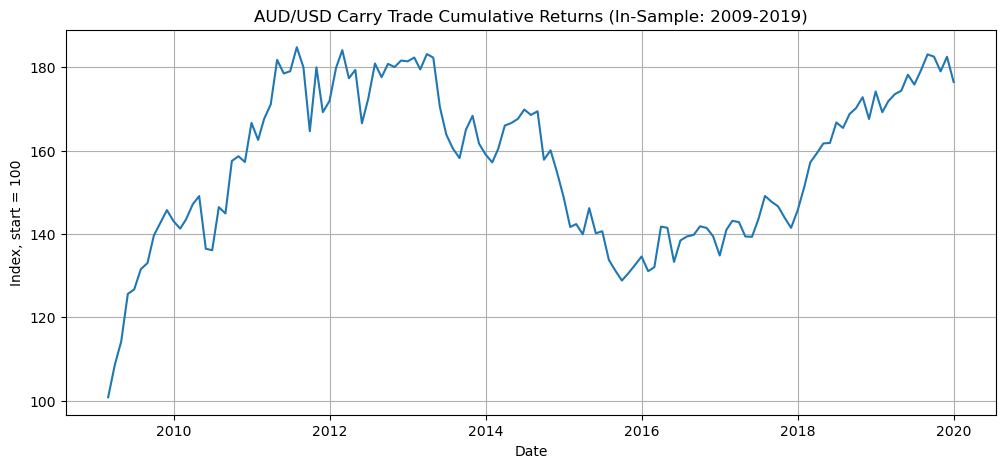

In [62]:
plt.figure(figsize=(12, 5))
plt.plot(insample["Date"], insample["cum_index"])
plt.title("AUD/USD Carry Trade Cumulative Returns (In-Sample: 2009-2019)")
plt.xlabel("Date")
plt.ylabel("Index, start = 100")
plt.grid(True)
plt.show()

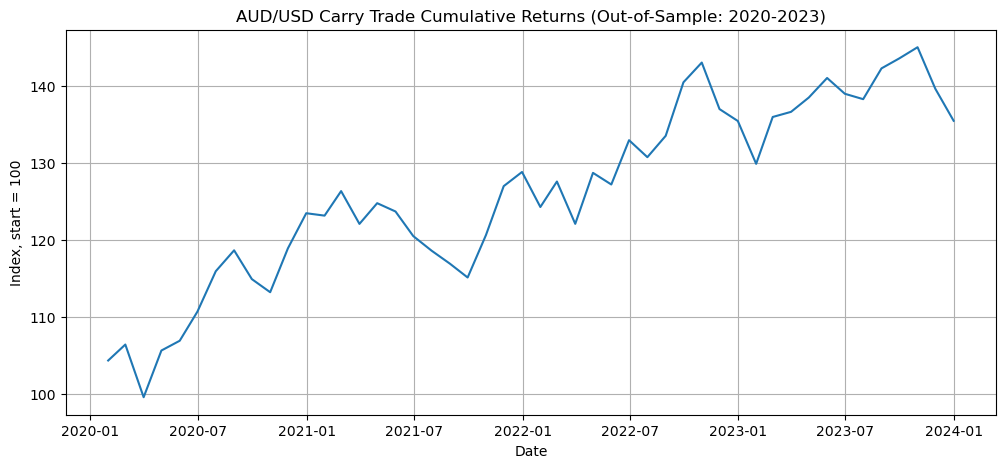

In [63]:
plt.figure(figsize=(12, 5))
plt.plot(oos["Date"], oos["cum_index"])
plt.title("AUD/USD Carry Trade Cumulative Returns (Out-of-Sample: 2020-2023)")
plt.xlabel("Date")
plt.ylabel("Index, start = 100")
plt.grid(True)
plt.show()

In [64]:
strategy_data.to_csv(PROCESSED_DIR / "audusd_strategy_data.csv", index=False)

In [65]:
insample["year"] = insample["Date"].dt.year
oos["year"] = oos["Date"].dt.year

insample_yearly = insample.groupby("year")["strategy_return"].apply(lambda x: (1 + x).prod() - 1)
oos_yearly = oos.groupby("year")["strategy_return"].apply(lambda x: (1 + x).prod() - 1)

print("In-sample yearly returns:")
print(insample_yearly.sort_index())

print("\nOut-of-sample yearly returns:")
print(oos_yearly.sort_index())

In-sample yearly returns:
year
2009    0.430852
2010    0.164731
2011    0.031445
2012    0.055386
2013   -0.123148
2014   -0.064128
2015   -0.095849
2016    0.001754
2017    0.080504
2018    0.195592
2019    0.013056
Name: strategy_return, dtype: float64

Out-of-sample yearly returns:
year
2020    0.234506
2021    0.043344
2022    0.051334
2023    0.000199
Name: strategy_return, dtype: float64


In [66]:
insample["roll12"] = (1 + insample["strategy_return"]).rolling(12).apply(np.prod, raw=True) - 1
oos["roll12"] = (1 + oos["strategy_return"]).rolling(12).apply(np.prod, raw=True) - 1

print("Best in-sample 12M window:")
print(insample.loc[insample["roll12"].idxmax(), ["Date", "roll12"]])

print("Worst in-sample 12M window:")
print(insample.loc[insample["roll12"].idxmin(), ["Date", "roll12"]])

print("\nBest OOS 12M window:")
print(oos.loc[oos["roll12"].idxmax(), ["Date", "roll12"]])

print("Worst OOS 12M window:")
print(oos.loc[oos["roll12"].idxmin(), ["Date", "roll12"]])

Best in-sample 12M window:
Date      2010-02-28 00:00:00
roll12               0.423445
Name: 12, dtype: object
Worst in-sample 12M window:
Date      2015-08-31 00:00:00
roll12              -0.225947
Name: 78, dtype: object

Best OOS 12M window:
Date      2020-12-31 00:00:00
roll12               0.234506
Name: 142, dtype: object
Worst OOS 12M window:
Date      2021-08-31 00:00:00
roll12              -0.014586
Name: 150, dtype: object


In [67]:
oos_2021 = oos[oos["Date"] <= "2021-12-31"].copy()
oos_2021["cum_index"] = 100 * (1 + oos_2021["strategy_return"]).cumprod()

print("OOS cumulative index at end-2021:", oos_2021["cum_index"].iloc[-1])
print("OOS cumulative index at end-2023:", oos["cum_index"].iloc[-1])

OOS cumulative index at end-2021: 128.80144378356022
OOS cumulative index at end-2023: 135.4402978086363
